# MOSAIC v0.4.0 — One Analysis per Hypothesis

This notebook performs one reproducible analysis for each of the seven
pre-specified MOSAIC hypotheses.

The design is paired by random seed. Each seed is treated as a matched block
across experimental conditions. The notebook uses non-parametric
repeated-measures tests because several model outcomes are bounded, discrete,
skewed, or tied.

**Significance level:** 0.05  
**Multiple-comparison method:** Holm correction within each planned family  
**Canonical dataset:** `MOSAIC_All_Experiments_Master_Runs.csv`


## Hypothesis register

| ID | Experiment | Hypothesis |
|---|---|---|
| H1 | BS01 | Baseline completion exceeds the 90% operational benchmark while recorded invariants remain valid. |
| H2 | BS02 | Leader-priority rewards increase inequality and coordination friction without improving completion. |
| H3 | BS03 | Communication reach matters more than moderate temporary link failure. |
| H4 | BS04 | Moderate capability heterogeneity outperforms both extreme conditions. |
| H5 | BS05 | High cooperative demand creates a nonlinear coordination-capacity threshold. |
| H6 | BS06 | Reputation and adaptation provide their strongest benefit when jointly enabled. |
| H7 | BS07 | Mission incentives saturate: payouts rise without reliable completion gains. |


In [1]:
from pathlib import Path
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=RuntimeWarning)

PACKAGE_NAME = "MOSAIC_v0.4.0_Final_Dataset_Colab"

candidate_roots = [
    Path("/content") / PACKAGE_NAME,
    Path("/mnt/data") / PACKAGE_NAME,
    Path.cwd() / PACKAGE_NAME,
]

DATA_ROOT = next((path for path in candidate_roots if path.exists()), None)

if DATA_ROOT is None:
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            "Dataset package not found. Upload "
            "MOSAIC_v0.4.0_Final_Dataset_Colab.zip."
        ) from exc

    uploaded = files.upload()
    zip_name = next(iter(uploaded))
    with zipfile.ZipFile(zip_name, "r") as archive:
        archive.extractall("/content")
    DATA_ROOT = Path("/content") / PACKAGE_NAME

MASTER_CSV = (
    DATA_ROOT
    / "processed"
    / "MOSAIC_All_Experiments_Master_Runs.csv"
)

OUTPUT_DIR = DATA_ROOT.parent / "MOSAIC_Hypothesis_Analysis_Outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(MASTER_CSV)

assert df.shape == (690, 49), f"Unexpected dataset shape: {df.shape}"
assert not df.duplicated().any()
assert not df.duplicated(["Experiment", "Condition", "Seed"]).any()

expected_counts = {
    "BS01": 30,
    "BS02": 120,
    "BS03": 120,
    "BS04": 90,
    "BS05": 90,
    "BS06": 120,
    "BS07": 120,
}
assert df["Experiment"].value_counts().sort_index().to_dict() == expected_counts

print("Dataset validation: PASS")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Output directory: {OUTPUT_DIR}")


Dataset validation: PASS
Rows: 690
Columns: 49
Output directory: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs


In [2]:
def bootstrap_mean_ci(values, confidence=0.95, n_boot=20_000, seed=20260731):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot)
    for index in range(n_boot):
        boot_means[index] = rng.choice(values, size=len(values), replace=True).mean()
    alpha = 1 - confidence
    return tuple(np.quantile(boot_means, [alpha / 2, 1 - alpha / 2]))


def rank_biserial_from_differences(differences):
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]
    differences = differences[differences != 0]
    if len(differences) == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(differences))
    positive = ranks[differences > 0].sum()
    negative = ranks[differences < 0].sum()
    denominator = positive + negative
    return float((positive - negative) / denominator) if denominator else 0.0


def one_sample_wilcoxon(differences, alternative="two-sided"):
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]
    result = stats.wilcoxon(
        differences,
        alternative=alternative,
        zero_method="wilcox",
        method="auto",
    )
    return {
        "W": float(result.statistic),
        "p": float(result.pvalue),
        "rank_biserial": rank_biserial_from_differences(differences),
        "mean_difference": float(np.mean(differences)),
        "median_difference": float(np.median(differences)),
        "n": int(len(differences)),
    }


def paired_wilcoxon(first, second, alternative="two-sided"):
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    return one_sample_wilcoxon(first - second, alternative=alternative)


def friedman_result(wide):
    result = stats.friedmanchisquare(
        *[wide[column].to_numpy() for column in wide.columns]
    )
    n = len(wide)
    k = wide.shape[1]
    kendalls_w = float(result.statistic / (n * (k - 1)))
    return {
        "chi_square": float(result.statistic),
        "df": int(k - 1),
        "p": float(result.pvalue),
        "kendalls_w": kendalls_w,
        "n": int(n),
        "k": int(k),
    }


def apply_holm(records, p_field="p"):
    adjusted = multipletests(
        [record[p_field] for record in records],
        alpha=0.05,
        method="holm",
    )
    for record, reject, adjusted_p in zip(records, adjusted[0], adjusted[1]):
        record["p_holm"] = float(adjusted_p)
        record["reject_holm"] = bool(reject)
    return records


def factorial_contrasts_2x2(data, outcome):
    wide = data.pivot(
        index="Seed",
        columns=["Factor 1 Level", "Factor 2 Level"],
        values=outcome,
    ).sort_index(axis=1)

    factor_1_levels = sorted(data["Factor 1 Level"].dropna().unique())
    factor_2_levels = sorted(data["Factor 2 Level"].dropna().unique())

    low_1, high_1 = factor_1_levels
    low_2, high_2 = factor_2_levels

    cell_00 = wide[(low_1, low_2)]
    cell_01 = wide[(low_1, high_2)]
    cell_10 = wide[(high_1, low_2)]
    cell_11 = wide[(high_1, high_2)]

    factor_1_effect = ((cell_10 + cell_11) / 2) - ((cell_00 + cell_01) / 2)
    factor_2_effect = ((cell_01 + cell_11) / 2) - ((cell_00 + cell_10) / 2)
    interaction = (cell_11 - cell_10) - (cell_01 - cell_00)

    return {
        "wide": wide,
        "factor_1_levels": factor_1_levels,
        "factor_2_levels": factor_2_levels,
        "factor_1_effect": factor_1_effect,
        "factor_2_effect": factor_2_effect,
        "interaction": interaction,
    }


def condition_summary(data, outcome, order=None):
    summary = (
        data.groupby("Condition", observed=True)[outcome]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )
    if order is not None:
        summary["Condition"] = pd.Categorical(
            summary["Condition"],
            categories=order,
            ordered=True,
        )
        summary = summary.sort_values("Condition").reset_index(drop=True)

    ci_values = []
    for condition in summary["Condition"].astype(str):
        values = data.loc[data["Condition"].astype(str) == condition, outcome]
        low, high = bootstrap_mean_ci(values)
        ci_values.append((low, high))

    summary["mean_ci_low"] = [item[0] for item in ci_values]
    summary["mean_ci_high"] = [item[1] for item in ci_values]
    return summary


def save_table(table, filename):
    path = TABLE_DIR / filename
    table.to_csv(path, index=False)
    print(f"Saved table: {path}")
    return path


def plot_condition_means(data, outcome, order, xlabel, filename):
    summary = condition_summary(data, outcome, order)
    x = np.arange(len(order))
    y = summary["mean"].to_numpy()
    lower = y - summary["mean_ci_low"].to_numpy()
    upper = summary["mean_ci_high"].to_numpy() - y

    plt.figure(figsize=(9, 5.5))
    plt.errorbar(
        x,
        y,
        yerr=np.vstack([lower, upper]),
        marker="o",
        capsize=5,
        linewidth=1.5,
    )
    plt.xticks(x, order, rotation=20, ha="right")
    plt.xlabel(xlabel)
    plt.ylabel(outcome)
    plt.tight_layout()
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")
    return summary


hypothesis_decisions = []


## H1 — Baseline mission viability

**Hypothesis.** Under the validated baseline, decentralized coordination will
achieve task completion above the 90% operational benchmark while all recorded
run-level invariants remain valid.

This is a baseline validation analysis, not a treatment comparison.


,Metric,Mean,SD,Median
0,Completion Rate (%),92.2222,6.7994,93.3333
1,Information Coverage (%),95.1556,3.3440,96.1111
2,Coalition Success (%),78.2404,12.1718,78.1746
3,Mission Efficiency,1.4818,0.5414,1.5383
4,Reward Gini,0.2957,0.0708,0.2893


Completion mean: 92.22%
Bootstrap 95% CI for mean: [89.67, 94.44]
Runs at or above 90%: 23/30
One-sided Wilcoxon against 90%: W=231.0, p=0.0098, rank-biserial=0.540
Recorded invariant checks: {'Task State Pass': True, 'Reputation Bounds Pass': True, 'Strategy Validity Pass': True}


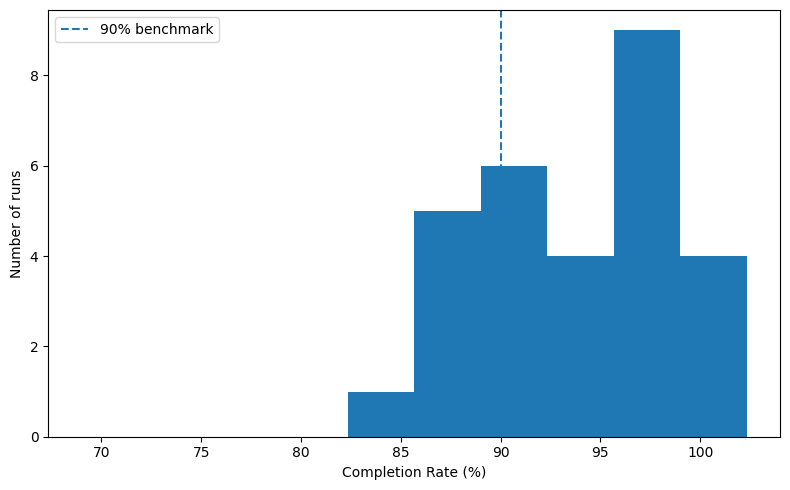

Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H1_Baseline_Summary.csv


In [3]:
h1 = df[df["Experiment"] == "BS01"].copy()

completion = h1["Completion Rate (%)"].to_numpy()
completion_ci = bootstrap_mean_ci(completion)
completion_test = one_sample_wilcoxon(
    completion - 90,
    alternative="greater",
)

h1_summary = pd.DataFrame({
    "Metric": [
        "Completion Rate (%)",
        "Information Coverage (%)",
        "Coalition Success (%)",
        "Mission Efficiency",
        "Reward Gini",
    ],
    "Mean": [
        h1["Completion Rate (%)"].mean(),
        h1["Information Coverage (%)"].mean(),
        h1["Coalition Success (%)"].mean(),
        h1["Mission Efficiency"].mean(),
        h1["Reward Gini"].mean(),
    ],
    "SD": [
        h1["Completion Rate (%)"].std(ddof=1),
        h1["Information Coverage (%)"].std(ddof=1),
        h1["Coalition Success (%)"].std(ddof=1),
        h1["Mission Efficiency"].std(ddof=1),
        h1["Reward Gini"].std(ddof=1),
    ],
    "Median": [
        h1["Completion Rate (%)"].median(),
        h1["Information Coverage (%)"].median(),
        h1["Coalition Success (%)"].median(),
        h1["Mission Efficiency"].median(),
        h1["Reward Gini"].median(),
    ],
})

display(h1_summary.round(4))

print(f"Completion mean: {completion.mean():.2f}%")
print(f"Bootstrap 95% CI for mean: [{completion_ci[0]:.2f}, {completion_ci[1]:.2f}]")
print(f"Runs at or above 90%: {(completion >= 90).sum()}/30")
print(
    "One-sided Wilcoxon against 90%: "
    f"W={completion_test['W']:.1f}, "
    f"p={completion_test['p']:.4f}, "
    f"rank-biserial={completion_test['rank_biserial']:.3f}"
)

recorded_checks = {
    "Task State Pass": bool(h1["Task State Pass"].all()),
    "Reputation Bounds Pass": bool(h1["Reputation Bounds Pass"].all()),
    "Strategy Validity Pass": bool(h1["Strategy Validity Pass"].all()),
}
print("Recorded invariant checks:", recorded_checks)

plt.figure(figsize=(8, 5))
plt.hist(completion, bins=np.arange(69, 104, 3.333333))
plt.axvline(90, linestyle="--", linewidth=1.5, label="90% benchmark")
plt.xlabel("Completion Rate (%)")
plt.ylabel("Number of runs")
plt.legend()
plt.tight_layout()
h1_figure = FIGURE_DIR / "H1_Baseline_Completion_Distribution.png"
plt.savefig(h1_figure, dpi=300, bbox_inches="tight")
plt.show()

save_table(h1_summary, "H1_Baseline_Summary.csv")

h1_decision = (
    "Supported with caution"
    if completion_test["p"] < 0.05 and all(recorded_checks.values())
    else "Not supported"
)
hypothesis_decisions.append({
    "Hypothesis": "H1",
    "Primary result": "Completion above 90% benchmark",
    "Statistic": completion_test["W"],
    "p_value": completion_test["p"],
    "Decision": h1_decision,
    "Interpretation": (
        "Central tendency exceeds 90% and recorded invariants pass, "
        "although the bootstrap confidence interval for the mean overlaps 90%."
    ),
})


## H2 — Reward-regime trade-off

**Hypothesis.** Leader-priority reward allocation will increase reward
inequality and coordination friction relative to equal-share without improving
task completion.

The performance, distributional, and friction outcomes are analysed
separately.


,Outcome,chi_square,df,p,kendalls_w,n,k
0,Completion Rate (%),0.995951,3,0.802232,0.011066,30,4
1,Reward Gini,8.939394,3,0.030108,0.099327,30,4
2,Unresolved Auction Rounds,27.763251,3,0.000004,0.308481,30,4
3,Coordination Overhead,7.770318,3,0.051005,0.086337,30,4


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H2_Global_Friedman_Tests.csv


,Outcome,First,Second,mean_difference,median_difference,rank_biserial,p,p_holm,reject_holm
0,Completion Rate (%),leader-priority,equal-share,-0.111111,0.000000,-0.070769,0.756611,1.000000,False
1,Completion Rate (%),leader-priority,contribution-based,-0.000000,0.000000,-0.036232,0.878597,1.000000,False
2,Completion Rate (%),leader-priority,mission-aligned,1.000000,0.000000,0.181159,0.446241,1.000000,False
3,Reward Gini,leader-priority,equal-share,0.043189,0.048790,0.522581,0.011303,0.022606,True
4,Reward Gini,leader-priority,contribution-based,0.049585,0.047781,0.754839,0.000123,0.000370,True
5,Reward Gini,leader-priority,mission-aligned,0.039397,0.045450,0.501075,0.015460,0.022606,True
6,Unresolved Auction Rounds,leader-priority,equal-share,229.633333,180.000000,0.827957,0.000016,0.000042,True
7,Unresolved Auction Rounds,leader-priority,contribution-based,201.933333,176.500000,0.780645,0.000189,0.000189,True
8,Unresolved Auction Rounds,leader-priority,mission-aligned,231.600000,182.000000,0.832258,0.000014,0.000042,True
9,Coordination Overhead,leader-priority,equal-share,20.095674,21.542989,0.556989,0.006640,0.019919,True


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H2_Planned_Paired_Comparisons.csv


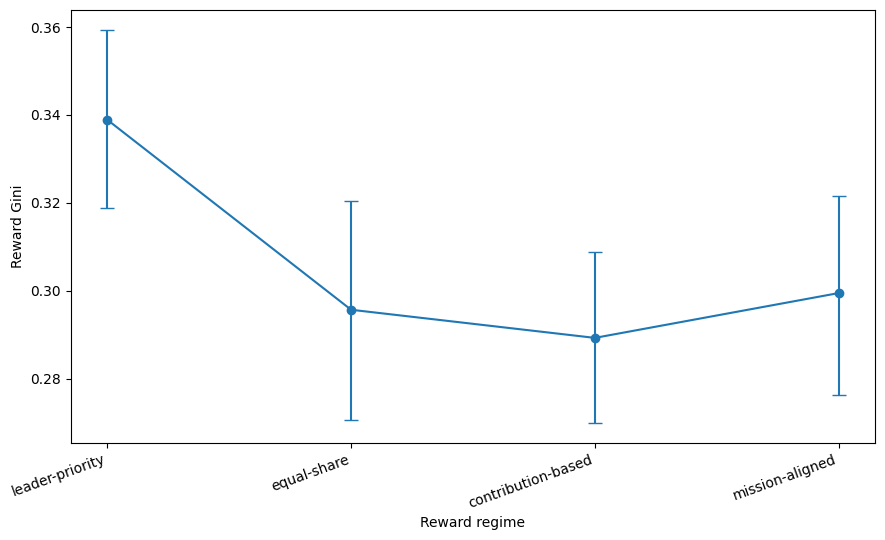

Saved figure: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/figures/H2_Reward_Gini_by_Regime.png
Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H2_Reward_Gini_Condition_Summary.csv


In [4]:
h2 = df[df["Experiment"] == "BS02"].copy()
h2_order = [
    "leader-priority",
    "equal-share",
    "contribution-based",
    "mission-aligned",
]

h2_global_records = []
for outcome in [
    "Completion Rate (%)",
    "Reward Gini",
    "Unresolved Auction Rounds",
    "Coordination Overhead",
]:
    wide = h2.pivot(index="Seed", columns="Condition", values=outcome)[h2_order]
    result = friedman_result(wide)
    result["Outcome"] = outcome
    h2_global_records.append(result)

h2_global = pd.DataFrame(h2_global_records)[
    ["Outcome", "chi_square", "df", "p", "kendalls_w", "n", "k"]
]
display(h2_global.round(6))
save_table(h2_global, "H2_Global_Friedman_Tests.csv")

planned_pairs = [
    ("leader-priority", "equal-share"),
    ("leader-priority", "contribution-based"),
    ("leader-priority", "mission-aligned"),
]

h2_pairwise_records = []
for outcome in [
    "Completion Rate (%)",
    "Reward Gini",
    "Unresolved Auction Rounds",
    "Coordination Overhead",
]:
    wide = h2.pivot(index="Seed", columns="Condition", values=outcome)
    outcome_records = []
    for first, second in planned_pairs:
        result = paired_wilcoxon(wide[first], wide[second])
        result.update({
            "Outcome": outcome,
            "First": first,
            "Second": second,
        })
        outcome_records.append(result)
    apply_holm(outcome_records)
    h2_pairwise_records.extend(outcome_records)

h2_pairwise = pd.DataFrame(h2_pairwise_records)
display(
    h2_pairwise[
        [
            "Outcome", "First", "Second", "mean_difference",
            "median_difference", "rank_biserial", "p", "p_holm",
            "reject_holm"
        ]
    ].round(6)
)
save_table(h2_pairwise, "H2_Planned_Paired_Comparisons.csv")

h2_summary = plot_condition_means(
    h2,
    "Reward Gini",
    h2_order,
    "Reward regime",
    "H2_Reward_Gini_by_Regime.png",
)
save_table(h2_summary, "H2_Reward_Gini_Condition_Summary.csv")

completion_global_p = h2_global.loc[
    h2_global["Outcome"] == "Completion Rate (%)", "p"
].iloc[0]
gini_equal = h2_pairwise[
    (h2_pairwise["Outcome"] == "Reward Gini")
    & (h2_pairwise["Second"] == "equal-share")
]["p_holm"].iloc[0]
friction_equal = h2_pairwise[
    (h2_pairwise["Outcome"] == "Unresolved Auction Rounds")
    & (h2_pairwise["Second"] == "equal-share")
]["p_holm"].iloc[0]

h2_supported = (
    completion_global_p >= 0.05
    and gini_equal < 0.05
    and friction_equal < 0.05
)

hypothesis_decisions.append({
    "Hypothesis": "H2",
    "Primary result": "Leader-priority trade-off",
    "Statistic": h2_global.loc[
        h2_global["Outcome"] == "Unresolved Auction Rounds",
        "chi_square"
    ].iloc[0],
    "p_value": h2_global.loc[
        h2_global["Outcome"] == "Unresolved Auction Rounds",
        "p"
    ].iloc[0],
    "Decision": "Supported" if h2_supported else "Not supported",
    "Interpretation": (
        "Leader-priority raises inequality and unresolved auction rounds "
        "relative to equal-share, while completion does not differ by regime."
    ),
})


## H3 — Communication structure

**Hypothesis.** Structural communication reach will have a larger beneficial
effect on mission outcomes than a moderate increase in temporary link failure.

The 2×2 paired design is analysed through within-seed main-effect and
interaction contrasts.


,Outcome,Contrast,mean_difference,median_difference,rank_biserial,p,p_holm,reject_holm
0,Completion Rate (%),Communication radius,3.555556,3.333333,0.826211,0.000221,0.000663,True
1,Completion Rate (%),Failure rate,0.111111,0.000000,0.012315,0.954489,1.000000,False
2,Completion Rate (%),Radius × failure interaction,0.666667,0.000000,0.100985,0.640166,1.000000,False
3,Information Coverage (%),Communication radius,7.355556,5.944444,0.952688,0.000000,0.000000,True
4,Information Coverage (%),Failure rate,0.311111,-0.055556,0.012903,0.950791,1.000000,False
5,Information Coverage (%),Radius × failure interaction,0.118519,2.000000,0.015054,0.942607,1.000000,False
6,Mean Coalition Delay,Communication radius,-32.802095,-35.920139,-0.987097,0.000000,0.000000,True
7,Mean Coalition Delay,Failure rate,4.400271,1.229573,0.260215,0.220647,0.441294,False
8,Mean Coalition Delay,Radius × failure interaction,7.098967,4.155357,0.225806,0.289366,0.441294,False
9,Coordination Overhead,Communication radius,-22.119462,-18.269964,-0.780645,0.000063,0.000189,True


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H3_Communication_Factorial_Contrasts.csv


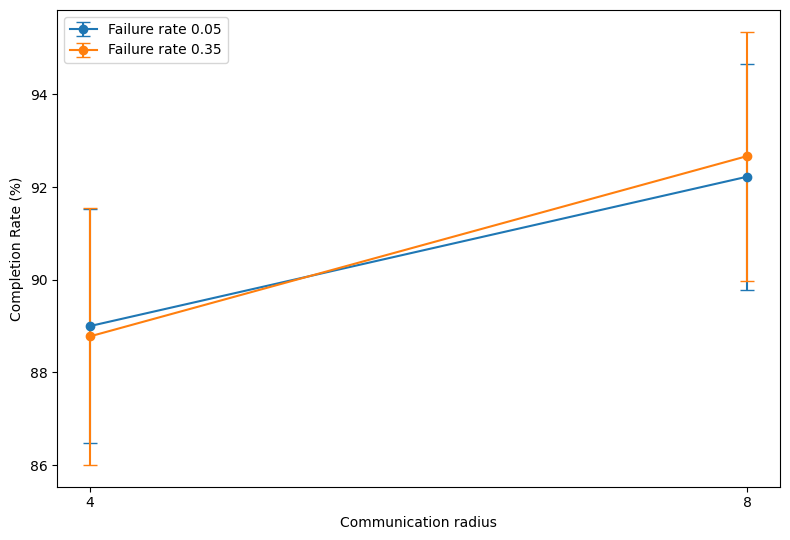

In [5]:
h3 = df[df["Experiment"] == "BS03"].copy()

h3_outcomes = [
    "Completion Rate (%)",
    "Information Coverage (%)",
    "Mean Coalition Delay",
    "Coordination Overhead",
    "Mission Efficiency",
]

h3_records = []
for outcome in h3_outcomes:
    contrasts = factorial_contrasts_2x2(h3, outcome)
    family = []
    for name, values in [
        ("Communication radius", contrasts["factor_1_effect"]),
        ("Failure rate", contrasts["factor_2_effect"]),
        ("Radius × failure interaction", contrasts["interaction"]),
    ]:
        result = one_sample_wilcoxon(values)
        result.update({
            "Outcome": outcome,
            "Contrast": name,
        })
        family.append(result)
    apply_holm(family)
    h3_records.extend(family)

h3_results = pd.DataFrame(h3_records)
display(
    h3_results[
        [
            "Outcome", "Contrast", "mean_difference", "median_difference",
            "rank_biserial", "p", "p_holm", "reject_holm"
        ]
    ].round(6)
)
save_table(h3_results, "H3_Communication_Factorial_Contrasts.csv")

# Interaction-style figure for the primary outcome.
h3_primary = (
    h3.groupby(["Factor 1 Level", "Factor 2 Level"], observed=True)
    ["Completion Rate (%)"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
h3_primary["se"] = h3_primary["std"] / np.sqrt(h3_primary["count"])
h3_primary["ci95"] = 1.96 * h3_primary["se"]

plt.figure(figsize=(8, 5.5))
for failure_level in sorted(h3_primary["Factor 2 Level"].unique()):
    subset = h3_primary[h3_primary["Factor 2 Level"] == failure_level]
    plt.errorbar(
        subset["Factor 1 Level"],
        subset["mean"],
        yerr=subset["ci95"],
        marker="o",
        capsize=5,
        label=f"Failure rate {failure_level}",
    )
plt.xlabel("Communication radius")
plt.ylabel("Completion Rate (%)")
plt.xticks(sorted(h3_primary["Factor 1 Level"].unique()))
plt.legend()
plt.tight_layout()
h3_figure = FIGURE_DIR / "H3_Communication_Completion_Interaction.png"
plt.savefig(h3_figure, dpi=300, bbox_inches="tight")
plt.show()

radius_primary = h3_results[
    (h3_results["Outcome"] == "Completion Rate (%)")
    & (h3_results["Contrast"] == "Communication radius")
].iloc[0]
failure_primary = h3_results[
    (h3_results["Outcome"] == "Completion Rate (%)")
    & (h3_results["Contrast"] == "Failure rate")
].iloc[0]

h3_supported = (
    radius_primary["mean_difference"] > 0
    and radius_primary["p_holm"] < 0.05
    and failure_primary["p_holm"] >= 0.05
)

hypothesis_decisions.append({
    "Hypothesis": "H3",
    "Primary result": "Communication-radius main effect",
    "Statistic": radius_primary["W"],
    "p_value": radius_primary["p_holm"],
    "Decision": "Supported" if h3_supported else "Not supported",
    "Interpretation": (
        "Increasing radius from 4 to 8 improves completion, information "
        "coverage, coalition delay, overhead, and mission efficiency. "
        "Moderate temporary failure has no reliable completion effect."
    ),
})


## H4 — Capability heterogeneity optimum

**Hypothesis.** Moderate capability heterogeneity (0.5) will outperform both
homogeneous (0.0) and highly heterogeneous (1.0) teams.

The planned contrast compares the moderate condition with the average of both
extreme conditions.


,Outcome,Friedman chi-square,Friedman p,Kendall W,Moderate-vs-extremes mean contrast,Moderate-vs-extremes W,Moderate-vs-extremes p,0.5 vs 0 p Holm,0.5 vs 1 p Holm
0,Completion Rate (%),12.355140,0.002075,0.205919,5.944444,375.0,0.000045,0.000377,0.000322
1,Mission Efficiency,20.866667,0.000029,0.347778,0.539832,448.0,0.000000,0.000000,0.000050


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H4_Heterogeneity_Optimum_Tests.csv


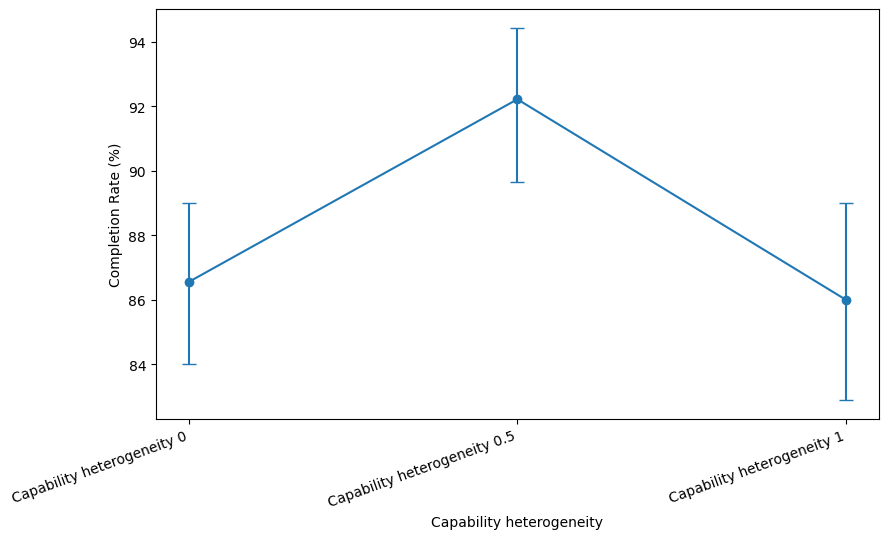

Saved figure: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/figures/H4_Completion_by_Heterogeneity.png
Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H4_Completion_Condition_Summary.csv


In [6]:
h4 = df[df["Experiment"] == "BS04"].copy()
h4_order = [
    "Capability heterogeneity 0",
    "Capability heterogeneity 0.5",
    "Capability heterogeneity 1",
]

h4_records = []
for outcome in ["Completion Rate (%)", "Mission Efficiency"]:
    wide = h4.pivot(index="Seed", columns="Condition", values=outcome)[h4_order]
    global_result = friedman_result(wide)

    moderate_vs_extremes = (
        wide[h4_order[1]]
        - (wide[h4_order[0]] + wide[h4_order[2]]) / 2
    )
    planned = one_sample_wilcoxon(
        moderate_vs_extremes,
        alternative="greater",
    )

    pair_records = []
    for extreme in [h4_order[0], h4_order[2]]:
        result = paired_wilcoxon(
            wide[h4_order[1]],
            wide[extreme],
            alternative="greater",
        )
        result.update({"Comparison": f"0.5 > {extreme.split()[-1]}"})
        pair_records.append(result)
    apply_holm(pair_records)

    h4_records.append({
        "Outcome": outcome,
        "Friedman chi-square": global_result["chi_square"],
        "Friedman p": global_result["p"],
        "Kendall W": global_result["kendalls_w"],
        "Moderate-vs-extremes mean contrast": planned["mean_difference"],
        "Moderate-vs-extremes W": planned["W"],
        "Moderate-vs-extremes p": planned["p"],
        "0.5 vs 0 p Holm": pair_records[0]["p_holm"],
        "0.5 vs 1 p Holm": pair_records[1]["p_holm"],
    })

h4_results = pd.DataFrame(h4_records)
display(h4_results.round(6))
save_table(h4_results, "H4_Heterogeneity_Optimum_Tests.csv")

h4_summary = plot_condition_means(
    h4,
    "Completion Rate (%)",
    h4_order,
    "Capability heterogeneity",
    "H4_Completion_by_Heterogeneity.png",
)
save_table(h4_summary, "H4_Completion_Condition_Summary.csv")

h4_primary = h4_results[h4_results["Outcome"] == "Completion Rate (%)"].iloc[0]
h4_supported = (
    h4_primary["Friedman p"] < 0.05
    and h4_primary["Moderate-vs-extremes p"] < 0.05
    and h4_primary["0.5 vs 0 p Holm"] < 0.05
    and h4_primary["0.5 vs 1 p Holm"] < 0.05
)

hypothesis_decisions.append({
    "Hypothesis": "H4",
    "Primary result": "Moderate-vs-extremes completion contrast",
    "Statistic": h4_primary["Moderate-vs-extremes W"],
    "p_value": h4_primary["Moderate-vs-extremes p"],
    "Decision": "Supported" if h4_supported else "Not supported",
    "Interpretation": (
        "The 0.5 condition has higher completion and mission efficiency "
        "than both 0.0 and 1.0."
    ),
})


## H5 — Cooperative-demand threshold

**Hypothesis.** Cooperative-task demand will create a nonlinear
coordination-capacity threshold, with the 0.8 condition causing a
disproportionately larger completion decline than the 0.4 condition.

The planned second-difference contrast is:

`2 × performance(0.4) − performance(0.0) − performance(0.8)`

A positive value indicates that the second increase in cooperative demand is
more damaging than the first.


,Outcome,Friedman chi-square,Friedman p,Kendall W,Planned contrast mean,Planned contrast median,Planned contrast W,Planned contrast p,Planned contrast rank-biserial
0,Completion Rate (%),50.324324,0.0,0.838739,9.888889,13.333333,355.5,0.001419,0.634483
1,Failed — Auction/No Feasible,45.230769,0.0,0.753846,3.133333,3.500000,399.0,0.000296,0.716129
2,Coalition Formation Efficiency (%),51.666667,0.0,0.861111,-1.284447,-0.677723,66.0,0.000313,-0.716129
3,Mean Coalition Delay,47.400000,0.0,0.790000,11.511360,13.737277,101.0,0.005776,0.565591


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H5_Cooperative_Demand_Threshold_Tests.csv


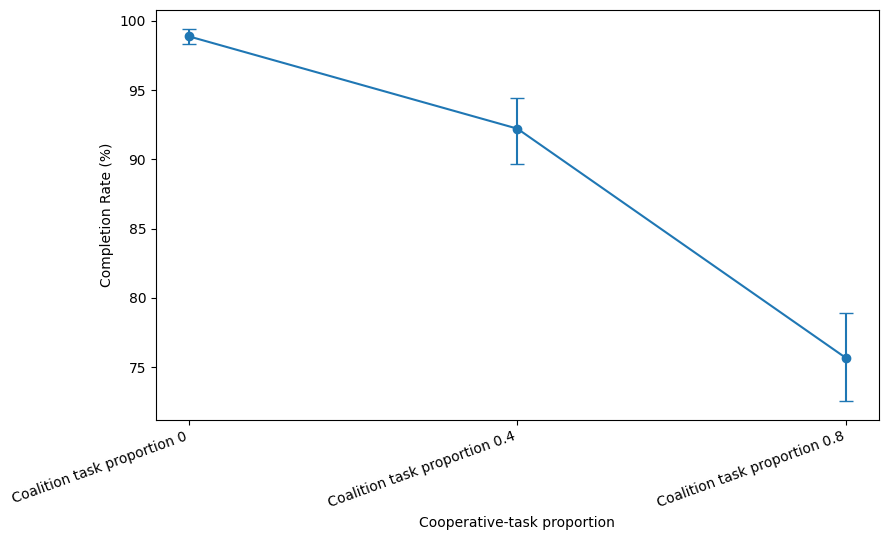

Saved figure: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/figures/H5_Completion_by_Cooperative_Demand.png
Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H5_Completion_Condition_Summary.csv


In [7]:
h5 = df[df["Experiment"] == "BS05"].copy()
h5_order = [
    "Coalition task proportion 0",
    "Coalition task proportion 0.4",
    "Coalition task proportion 0.8",
]

h5_outcomes = [
    "Completion Rate (%)",
    "Failed — Auction/No Feasible",
    "Coalition Formation Efficiency (%)",
    "Mean Coalition Delay",
]

h5_records = []
for outcome in h5_outcomes:
    wide = h5.pivot(index="Seed", columns="Condition", values=outcome)[h5_order]
    global_result = friedman_result(wide)

    if outcome == "Completion Rate (%)":
        threshold = (
            2 * wide[h5_order[1]]
            - wide[h5_order[0]]
            - wide[h5_order[2]]
        )
        alternative = "greater"
    elif outcome == "Failed — Auction/No Feasible":
        threshold = (
            wide[h5_order[2]]
            - 2 * wide[h5_order[1]]
            + wide[h5_order[0]]
        )
        alternative = "greater"
    else:
        threshold = (
            wide[h5_order[2]]
            - wide[h5_order[1]]
        )
        alternative = "two-sided"

    planned = one_sample_wilcoxon(threshold, alternative=alternative)

    h5_records.append({
        "Outcome": outcome,
        "Friedman chi-square": global_result["chi_square"],
        "Friedman p": global_result["p"],
        "Kendall W": global_result["kendalls_w"],
        "Planned contrast mean": planned["mean_difference"],
        "Planned contrast median": planned["median_difference"],
        "Planned contrast W": planned["W"],
        "Planned contrast p": planned["p"],
        "Planned contrast rank-biserial": planned["rank_biserial"],
    })

h5_results = pd.DataFrame(h5_records)
display(h5_results.round(6))
save_table(h5_results, "H5_Cooperative_Demand_Threshold_Tests.csv")

h5_summary = plot_condition_means(
    h5,
    "Completion Rate (%)",
    h5_order,
    "Cooperative-task proportion",
    "H5_Completion_by_Cooperative_Demand.png",
)
save_table(h5_summary, "H5_Completion_Condition_Summary.csv")

h5_primary = h5_results[
    h5_results["Outcome"] == "Completion Rate (%)"
].iloc[0]
h5_supported = (
    h5_primary["Friedman p"] < 0.05
    and h5_primary["Planned contrast p"] < 0.05
    and h5_primary["Planned contrast mean"] > 0
)

hypothesis_decisions.append({
    "Hypothesis": "H5",
    "Primary result": "Nonlinear completion threshold",
    "Statistic": h5_primary["Planned contrast W"],
    "p_value": h5_primary["Planned contrast p"],
    "Decision": "Supported" if h5_supported else "Not supported",
    "Interpretation": (
        "The completion loss from 0.4 to 0.8 is disproportionately larger "
        "than the loss from 0.0 to 0.4, consistent with coalition-capacity "
        "overload."
    ),
})


## H6 — Reputation and adaptation synergy

**Hypothesis.** Reputation and adaptive strategies will improve mission
outcomes most strongly when jointly enabled.

The primary endpoint is completion. Coalition delay is a secondary
coordination-process endpoint.


,Outcome,Contrast,mean_difference,median_difference,rank_biserial,p,p_holm,reject_holm
0,Completion Rate (%),Reputation main effect,0.277778,1.666667,0.055914,0.788810,1.000000,False
1,Completion Rate (%),Adaptation main effect,0.944444,0.833333,0.209360,0.332508,0.997525,False
2,Completion Rate (%),Reputation × adaptation interaction,0.777778,0.000000,0.094253,0.657332,1.000000,False
3,Mean Coalition Delay,Reputation main effect,-0.220057,-3.395833,-0.040860,0.855272,1.000000,False
4,Mean Coalition Delay,Adaptation main effect,-1.537308,1.494755,-0.105376,0.626346,1.000000,False
5,Mean Coalition Delay,Reputation × adaptation interaction,-9.646161,-12.020431,-0.548387,0.007612,0.022836,True


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H6_Reputation_Adaptation_Factorial_Contrasts.csv


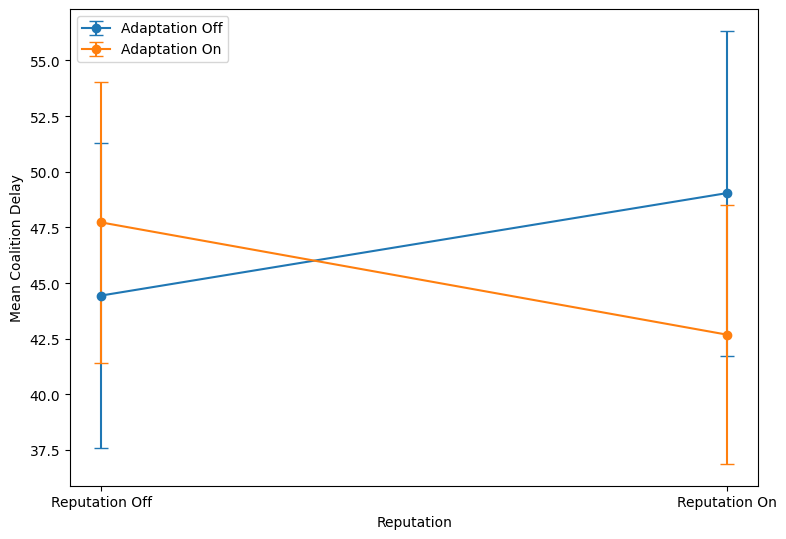

In [8]:
h6 = df[df["Experiment"] == "BS06"].copy()

h6_records = []
for outcome in ["Completion Rate (%)", "Mean Coalition Delay"]:
    contrasts = factorial_contrasts_2x2(h6, outcome)
    family = []
    for name, values in [
        ("Reputation main effect", contrasts["factor_1_effect"]),
        ("Adaptation main effect", contrasts["factor_2_effect"]),
        ("Reputation × adaptation interaction", contrasts["interaction"]),
    ]:
        result = one_sample_wilcoxon(values)
        result.update({
            "Outcome": outcome,
            "Contrast": name,
        })
        family.append(result)
    apply_holm(family)
    h6_records.extend(family)

h6_results = pd.DataFrame(h6_records)
display(
    h6_results[
        [
            "Outcome", "Contrast", "mean_difference", "median_difference",
            "rank_biserial", "p", "p_holm", "reject_holm"
        ]
    ].round(6)
)
save_table(h6_results, "H6_Reputation_Adaptation_Factorial_Contrasts.csv")

h6_delay = (
    h6.groupby(["Factor 1 Level", "Factor 2 Level"], observed=True)
    ["Mean Coalition Delay"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
h6_delay["se"] = h6_delay["std"] / np.sqrt(h6_delay["count"])
h6_delay["ci95"] = 1.96 * h6_delay["se"]

plt.figure(figsize=(8, 5.5))
for adaptation_level in sorted(h6_delay["Factor 2 Level"].unique()):
    subset = h6_delay[h6_delay["Factor 2 Level"] == adaptation_level]
    x = np.arange(len(subset))
    plt.errorbar(
        x,
        subset["mean"],
        yerr=subset["ci95"],
        marker="o",
        capsize=5,
        label=f"Adaptation {adaptation_level}",
    )
plt.xticks(
    [0, 1],
    ["Reputation Off", "Reputation On"],
)
plt.xlabel("Reputation")
plt.ylabel("Mean Coalition Delay")
plt.legend()
plt.tight_layout()
h6_figure = FIGURE_DIR / "H6_Coalition_Delay_Interaction.png"
plt.savefig(h6_figure, dpi=300, bbox_inches="tight")
plt.show()

completion_interaction = h6_results[
    (h6_results["Outcome"] == "Completion Rate (%)")
    & (
        h6_results["Contrast"]
        == "Reputation × adaptation interaction"
    )
].iloc[0]
delay_interaction = h6_results[
    (h6_results["Outcome"] == "Mean Coalition Delay")
    & (
        h6_results["Contrast"]
        == "Reputation × adaptation interaction"
    )
].iloc[0]

h6_primary_supported = (
    completion_interaction["p_holm"] < 0.05
    and completion_interaction["mean_difference"] > 0
)

hypothesis_decisions.append({
    "Hypothesis": "H6",
    "Primary result": "Reputation × adaptation completion interaction",
    "Statistic": completion_interaction["W"],
    "p_value": completion_interaction["p_holm"],
    "Decision": (
        "Not supported for primary outcome; secondary evidence"
        if not h6_primary_supported and delay_interaction["p_holm"] < 0.05
        else ("Supported" if h6_primary_supported else "Not supported")
    ),
    "Interpretation": (
        "The joint mechanisms do not reliably improve completion. "
        "Their interaction reduces coalition delay, indicating a process-level "
        "rather than mission-level benefit."
    ),
})


## H7 — Mission-incentive saturation

**Hypothesis.** Increasing mission-incentive strength will exhibit diminishing
returns: payments will rise monotonically while task completion will not
reliably improve.

Performance and economic outcomes are analysed jointly but are not collapsed
into a single arbitrary index.


,Outcome,chi_square,df,p,kendalls_w
0,Completion Rate (%),4.515152,3,0.210943,0.050168
1,Rewards Distributed,86.520000,3,0.000000,0.961333
2,Coalition Success (%),5.833333,3,0.120007,0.064815
3,Mission Efficiency,3.923077,3,0.269891,0.043590


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H7_Global_Friedman_Tests.csv


,Outcome,Condition,mean_difference,median_difference,rank_biserial,p,p_holm,reject_holm
0,Completion Rate (%),Mission incentive 0.1,0.444444,0.000000,0.357143,0.394627,0.789254,False
1,Completion Rate (%),Mission incentive 0.25,-1.111111,0.000000,-0.490909,0.167976,0.503929,False
2,Completion Rate (%),Mission incentive 0.5,-0.666667,0.000000,-0.179487,0.581755,0.789254,False
3,Rewards Distributed,Mission incentive 0.1,342.755998,334.680922,0.995699,0.000000,0.000000,True
4,Rewards Distributed,Mission incentive 0.25,759.182558,807.734734,1.000000,0.000000,0.000000,True
5,Rewards Distributed,Mission incentive 0.5,1632.896262,1624.079197,1.000000,0.000000,0.000000,True
6,Coalition Success (%),Mission incentive 0.1,3.695117,0.000000,0.911111,0.015156,0.045468,True
7,Coalition Success (%),Mission incentive 0.25,3.764269,0.000000,0.717949,0.028056,0.045468,True
8,Coalition Success (%),Mission incentive 0.5,4.442214,0.000000,0.695238,0.021944,0.045468,True


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H7_Paired_Comparisons_vs_Zero.csv


,Condition,Completion Rate (%),Rewards Distributed,Coalition Success (%),Incremental Completion vs 0 (pp),Incremental Rewards vs 0,Dominated by zero on completion and cost
0,Mission incentive 0,92.2222,3337.5770,78.2404,0.0000,0.0000,False
1,Mission incentive 0.1,92.6667,3680.3330,81.9355,0.4444,342.7560,False
2,Mission incentive 0.25,91.1111,4096.7596,82.0047,-1.1111,759.1826,True
3,Mission incentive 0.5,91.5556,4970.4733,82.6826,-0.6667,1632.8963,True


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/H7_Incremental_Cost_Performance.csv


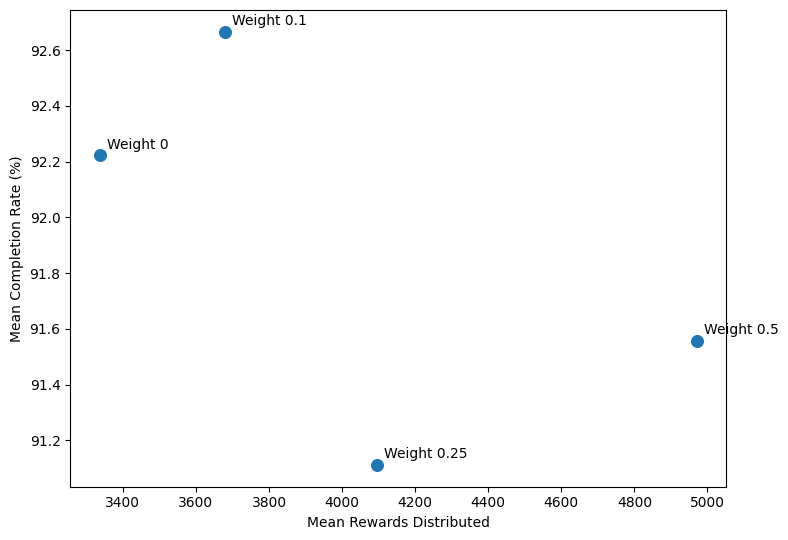

In [9]:
h7 = df[df["Experiment"] == "BS07"].copy()
h7_order = [
    "Mission incentive 0",
    "Mission incentive 0.1",
    "Mission incentive 0.25",
    "Mission incentive 0.5",
]

h7_global_records = []
for outcome in [
    "Completion Rate (%)",
    "Rewards Distributed",
    "Coalition Success (%)",
    "Mission Efficiency",
]:
    wide = h7.pivot(index="Seed", columns="Condition", values=outcome)[h7_order]
    result = friedman_result(wide)
    result["Outcome"] = outcome
    h7_global_records.append(result)

h7_global = pd.DataFrame(h7_global_records)
display(
    h7_global[
        ["Outcome", "chi_square", "df", "p", "kendalls_w"]
    ].round(6)
)
save_table(h7_global, "H7_Global_Friedman_Tests.csv")

h7_comparisons = []
baseline = h7_order[0]

for outcome in [
    "Completion Rate (%)",
    "Rewards Distributed",
    "Coalition Success (%)",
]:
    wide = h7.pivot(index="Seed", columns="Condition", values=outcome)
    family = []
    for condition in h7_order[1:]:
        result = paired_wilcoxon(wide[condition], wide[baseline])
        result.update({
            "Outcome": outcome,
            "Condition": condition,
            "Reference": baseline,
        })
        family.append(result)
    apply_holm(family)
    h7_comparisons.extend(family)

h7_pairwise = pd.DataFrame(h7_comparisons)
display(
    h7_pairwise[
        [
            "Outcome", "Condition", "mean_difference",
            "median_difference", "rank_biserial",
            "p", "p_holm", "reject_holm"
        ]
    ].round(6)
)
save_table(h7_pairwise, "H7_Paired_Comparisons_vs_Zero.csv")

condition_means = (
    h7.groupby("Condition", observed=True)[
        ["Completion Rate (%)", "Rewards Distributed", "Coalition Success (%)"]
    ]
    .mean()
    .reindex(h7_order)
)

cost_effectiveness = condition_means.copy()
cost_effectiveness["Incremental Completion vs 0 (pp)"] = (
    cost_effectiveness["Completion Rate (%)"]
    - cost_effectiveness.loc[baseline, "Completion Rate (%)"]
)
cost_effectiveness["Incremental Rewards vs 0"] = (
    cost_effectiveness["Rewards Distributed"]
    - cost_effectiveness.loc[baseline, "Rewards Distributed"]
)
cost_effectiveness["Dominated by zero on completion and cost"] = (
    (cost_effectiveness["Incremental Completion vs 0 (pp)"] <= 0)
    & (cost_effectiveness["Incremental Rewards vs 0"] > 0)
)
cost_effectiveness = cost_effectiveness.reset_index()
display(cost_effectiveness.round(4))
save_table(cost_effectiveness, "H7_Incremental_Cost_Performance.csv")

plt.figure(figsize=(8, 5.5))
plt.scatter(
    cost_effectiveness["Rewards Distributed"],
    cost_effectiveness["Completion Rate (%)"],
    s=70,
)
for _, row in cost_effectiveness.iterrows():
    plt.annotate(
        row["Condition"].replace("Mission incentive ", "Weight "),
        (
            row["Rewards Distributed"],
            row["Completion Rate (%)"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )
plt.xlabel("Mean Rewards Distributed")
plt.ylabel("Mean Completion Rate (%)")
plt.tight_layout()
h7_figure = FIGURE_DIR / "H7_Incentive_Cost_Performance.png"
plt.savefig(h7_figure, dpi=300, bbox_inches="tight")
plt.show()

completion_p = h7_global.loc[
    h7_global["Outcome"] == "Completion Rate (%)", "p"
].iloc[0]
rewards_p = h7_global.loc[
    h7_global["Outcome"] == "Rewards Distributed", "p"
].iloc[0]

rewards_monotonic = (
    condition_means["Rewards Distributed"].diff().dropna() > 0
).all()
h7_supported = (
    completion_p >= 0.05
    and rewards_p < 0.05
    and rewards_monotonic
)

hypothesis_decisions.append({
    "Hypothesis": "H7",
    "Primary result": "Completion versus payout divergence",
    "Statistic": h7_global.loc[
        h7_global["Outcome"] == "Rewards Distributed",
        "chi_square"
    ].iloc[0],
    "p_value": rewards_p,
    "Decision": "Supported" if h7_supported else "Not supported",
    "Interpretation": (
        "Rewards rise monotonically and strongly with incentive weight, "
        "but completion does not differ reliably. The 0.25 and 0.50 "
        "conditions cost more while producing lower mean completion than zero."
    ),
})


## Integrated hypothesis decisions

The decisions below distinguish primary-outcome support from secondary
process-level evidence. A non-significant result is not interpreted as proof
of equivalence.


In [10]:
decision_table = pd.DataFrame(hypothesis_decisions)
display(decision_table)

save_table(decision_table, "MOSAIC_Hypothesis_Decisions.csv")

print("\nGenerated figures:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("-", path.name)

print("\nGenerated tables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print("-", path.name)


,Hypothesis,Primary result,Statistic,p_value,Decision,Interpretation
0,H1,Completion above 90% benchmark,231.000000,9.813256e-03,Supported with caution,Central tendency exceeds 90% and recorded inva...
1,H2,Leader-priority trade-off,27.763251,4.072261e-06,Supported,Leader-priority raises inequality and unresolv...
2,H3,Communication-radius main effect,30.500000,6.633221e-04,Supported,Increasing radius from 4 to 8 improves complet...
3,H4,Moderate-vs-extremes completion contrast,375.000000,4.458118e-05,Supported,The 0.5 condition has higher completion and mi...
4,H5,Nonlinear completion threshold,355.500000,1.418880e-03,Supported,The completion loss from 0.4 to 0.8 is disprop...
5,H6,Reputation × adaptation completion interaction,197.000000,1.000000e+00,Not supported for primary outcome; secondary e...,The joint mechanisms do not reliably improve c...
6,H7,Completion versus payout divergence,86.520000,1.224206e-18,Supported,Rewards rise monotonically and strongly with i...


Saved table: /mnt/data/MOSAIC_Hypothesis_Analysis_Outputs/tables/MOSAIC_Hypothesis_Decisions.csv

Generated figures:
- H1_Baseline_Completion_Distribution.png
- H2_Reward_Gini_by_Regime.png
- H3_Communication_Completion_Interaction.png
- H4_Completion_by_Heterogeneity.png
- H5_Completion_by_Cooperative_Demand.png
- H6_Coalition_Delay_Interaction.png
- H7_Incentive_Cost_Performance.png

Generated tables:
- H1_Baseline_Summary.csv
- H2_Global_Friedman_Tests.csv
- H2_Planned_Paired_Comparisons.csv
- H2_Reward_Gini_Condition_Summary.csv
- H3_Communication_Factorial_Contrasts.csv
- H4_Completion_Condition_Summary.csv
- H4_Heterogeneity_Optimum_Tests.csv
- H5_Completion_Condition_Summary.csv
- H5_Cooperative_Demand_Threshold_Tests.csv
- H6_Reputation_Adaptation_Factorial_Contrasts.csv
- H7_Global_Friedman_Tests.csv
- H7_Incremental_Cost_Performance.csv
- H7_Paired_Comparisons_vs_Zero.csv
- MOSAIC_Hypothesis_Decisions.csv


## Interpretation constraints

1. These are simulation results, not empirical field estimates.
2. Findings apply to the implemented mechanisms and tested parameter ranges.
3. Paired seeds reduce stochastic comparison noise but do not eliminate model
   structural uncertainty.
4. Statistical significance does not establish practical importance.
5. The paper should report exact effect sizes, uncertainty, and limitations,
   not only p-values.
